In [1]:
%pip install pykan==0.2.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.6 MB/s eta 0:00:00


In [3]:
from kan import *
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [5]:
f = lambda x: x[:,0] * x[:,1]

In [6]:
dataset = create_dataset (
    f,
    n_var=2,
    train_num = 1000,
    test_num = 1000,
    device = device
)

print(dataset.keys())

dict_keys(['train_input', 'test_input', 'train_label', 'test_label'])


In [11]:
print('Train:')
print(dataset['train_input'][:5])
print(dataset['train_input'][:5])
print('Test:')
print(dataset['test_input'][:5])
print(dataset['test_input'][:5])
print('Etiquetas:')
print(dataset['train_label'][:5])
print(dataset['test_label'][:5])

Train:
tensor([[-0.0075,  0.5547],
        [ 0.5364,  0.1791],
        [-0.8230,  0.1526],
        [-0.7359,  0.5171],
        [-0.3852,  0.6230]], device='cuda:0')
tensor([[-0.0075,  0.5547],
        [ 0.5364,  0.1791],
        [-0.8230,  0.1526],
        [-0.7359,  0.5171],
        [-0.3852,  0.6230]], device='cuda:0')
Test:
tensor([[-0.0850, -0.2418],
        [-0.7799, -0.0967],
        [-0.0061, -0.4609],
        [-0.8300,  0.7118],
        [-0.2151,  0.5739]], device='cuda:0')
tensor([[-0.0850, -0.2418],
        [-0.7799, -0.0967],
        [-0.0061, -0.4609],
        [-0.8300,  0.7118],
        [-0.2151,  0.5739]], device='cuda:0')
Etiquetas:
tensor([[-0.0042],
        [ 0.0961],
        [-0.1256],
        [-0.3805],
        [-0.2400]], device='cuda:0')
tensor([[ 0.0206],
        [ 0.0754],
        [ 0.0028],
        [-0.5909],
        [-0.1235]], device='cuda:0')


In [14]:
import os
os.makedirs("./checkpoints_xy", exist_ok=True)

In [20]:
model = KAN(
    width=[2,2,1],
    grid=3,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./checkpoints_xy"
  )

checkpoint directory created: ./checkpoints_xy
saving model version 0.0


In [21]:
results = model.fit(
    dataset,
    opt='LBFGS',
    steps=20
)

| train_loss: 1.11e-03 | test_loss: 1.04e-03 | reg: 7.69e+00 | : 100%|█| 20/20 [00:09<00:00,  2.20it

saving model version 0.1


In [22]:
print(results.keys())

dict_keys(['train_loss', 'test_loss', 'reg'])


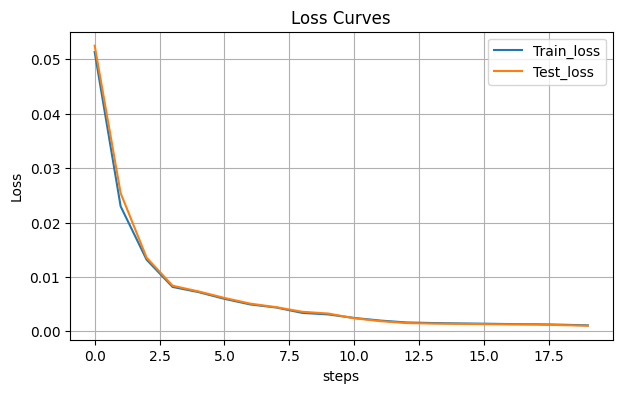

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(results['train_loss'], label='Train_loss')
plt.plot(results['test_loss'], label='Test_loss')
plt.ylabel('Loss')
plt.xlabel('steps')
plt.legend()
plt.title('Loss Curves')
plt.grid(True)
plt.show()

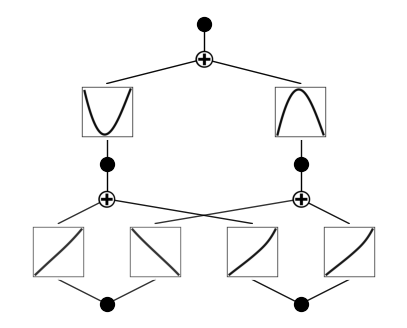

In [29]:
plot_folder = './plots_xy'
os.makedirs(plot_folder, exist_ok=True)

model.plot()
plt.savefig(os.path.join(plot_folder, 'model_plot_xy.png'))
plt.show()

In [44]:
from kan.spline import coef2curve

def plot_one_splines(
    model,
    layer_idx = 0,
    input_idx = 0,
    output_idx = 0,
    X=None,
    input_name = None,
    output_name = None,
    output_idx_name = None,
    n_points=300,
    device=None
  ):
    if device is None:
      device = next(model.parameters()).device

    layer = model.act_fun[layer_idx]
    grid = layer.grid
    coef = layer.coef
    scale_base = layer.scale_base
    scale_sp = layer.scale_sp

    # Obtener las dimesiones de la capa
    in_dim = coef.shape[0]
    out_dim = coef.shape[1]

    if input_idx >= in_dim:
      raise ValueError(f"input_idx {input_idx} must be less than in_dim {in_dim}")
    if output_idx >= out_dim:
      raise ValueError(f"output_idx {output_idx} must be less than out_dim {out_dim}")

    if  X is not None:
      x_min = X[:, input_idx].min().item()
      x_max = X[:, input_idx].max().item()
    else:
      x_min = -1
      x_max = 1

    X_eval = torch.linspace(x_min, x_max, n_points).reshape(-1,1).to(device)
    X_eval_layer = X_eval.repeat(1, in_dim)

    y_spline = coef2curve(
        X_eval_layer,
        grid,
        coef,
        model.k,
        device=device
    )

    base_eval = layer.base_fun(X_eval_layer)
    spline = y_spline[:, input_idx, output_idx]
    base = base_eval[:, input_idx]

    sb = scale_base[input_idx, output_idx]
    ss = scale_sp[input_idx, output_idx]

    full_function = sb*base + ss*spline
    base = sb*base
    spline = ss*spline

    if input_name is None:
      input_name = f"entrada_{input_idx}"
    if output_name is None:
      output_name = f"salida_{output_idx}"

    x_np = X_eval.detach().cpu().numpy()
    spline_np = spline.detach().cpu().numpy()
    base_np = base.detach().cpu().numpy()
    full_function_np = full_function.detach().cpu().numpy()

    plt.figure(figsize=(10,5))
    plt.plot(x_np, spline_np, label="Spline Aprendida")
    plt.plot(x_np, base_np, label="Parte base")
    plt.plot(x_np, full_function_np, label="Función completa")
    plt.xlabel(input_name)
    plt.ylabel(output_name)
    plt.title(f"Función Spline {input_name} -> {output_name}")
    plt.grid(True)
    plt.legend()
    plt.show()

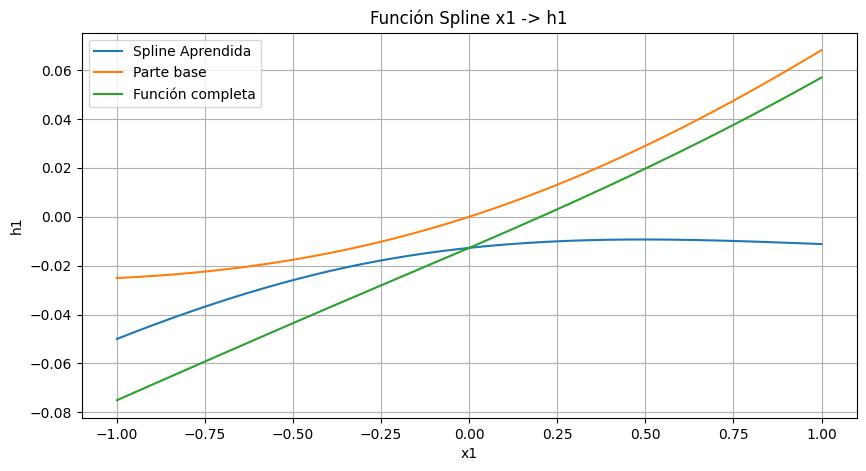

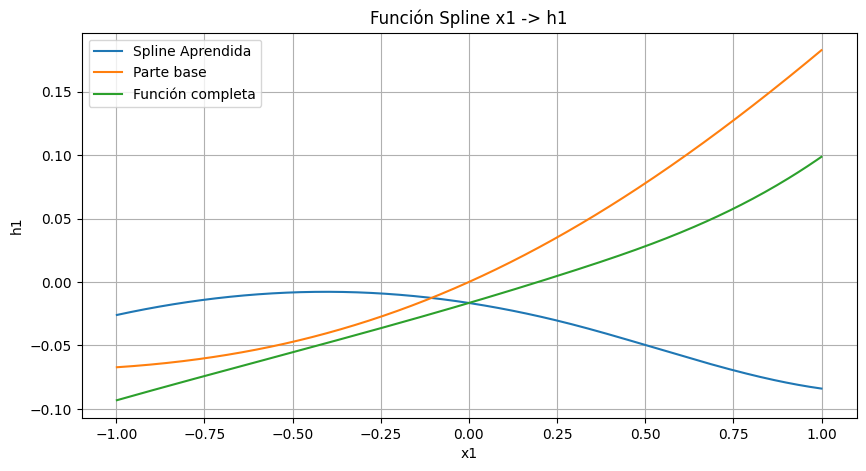

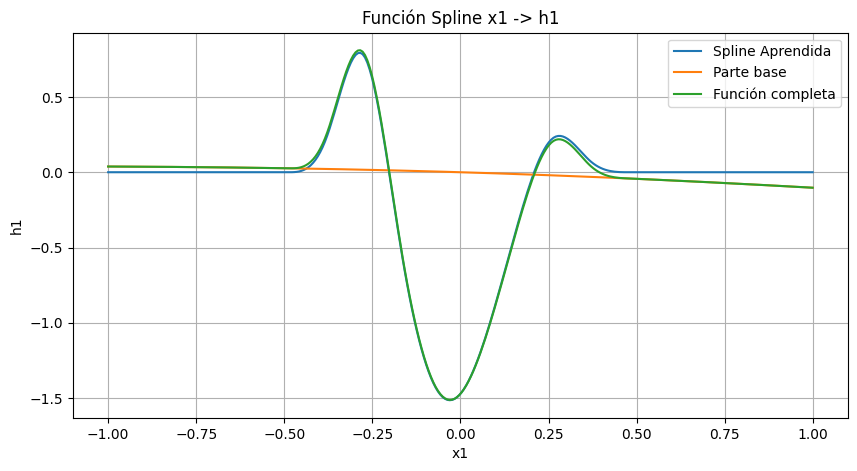

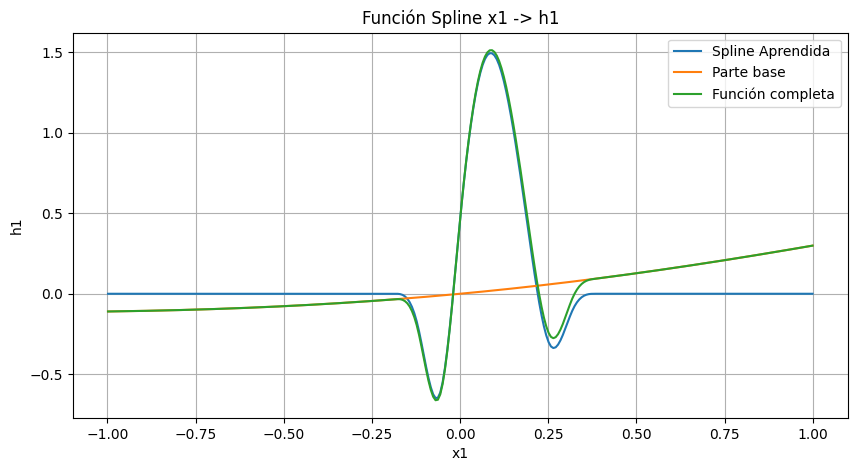

In [58]:
for i in range(2):
  for j in range(2):
    plot_one_splines(
        model,
        layer_idx = i,
        input_idx = j,
        output_idx = 0,
        X=dataset['train_input'],
        input_name = 'x1',
        output_name = 'h1',
        device=device
    )